# Visualization with FDFI

This tutorial shows the plotting helpers in `fdfi.plots` for background data, aggregate FDFI scores, per-sample UEIFs, inference output, and explainer diagnostics.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

from fdfi.explainers import OTExplainer
from fdfi.plots import (
    confidence_interval_plot,
    correlation_heatmap,
    dependence_plot,
    diagnostics_plot,
    force_plot,
    summary_bar,
    summary_plot,
    waterfall_plot,
)

rng = np.random.default_rng(42)

## Simulated Data

Use a small correlated background matrix so the correlation heatmap and dependence plot have structure.

In [2]:
n_train = 200
n_test = 60
n_features = 6

cov = np.full((n_features, n_features), 0.25)
np.fill_diagonal(cov, 1.0)
cov[0, 1] = cov[1, 0] = 0.75
cov[2, 3] = cov[3, 2] = -0.55

X_background = rng.multivariate_normal(np.zeros(n_features), cov, size=n_train)
X_test = rng.multivariate_normal(np.zeros(n_features), cov, size=n_test)
feature_names = [f"X{i}" for i in range(n_features)]

def model(X):
    return 1.5 * X[:, 0] - 0.8 * X[:, 2] + 0.4 * X[:, 4] ** 2

explainer = OTExplainer(model, data=X_background, nsamples=40)
results = explainer(X_test)
ci = explainer.conf_int(alpha=0.05, target="X", alternative="greater")

## Background Correlation

`correlation_heatmap` clusters features by `1 - abs(correlation)` and returns the reordered names.

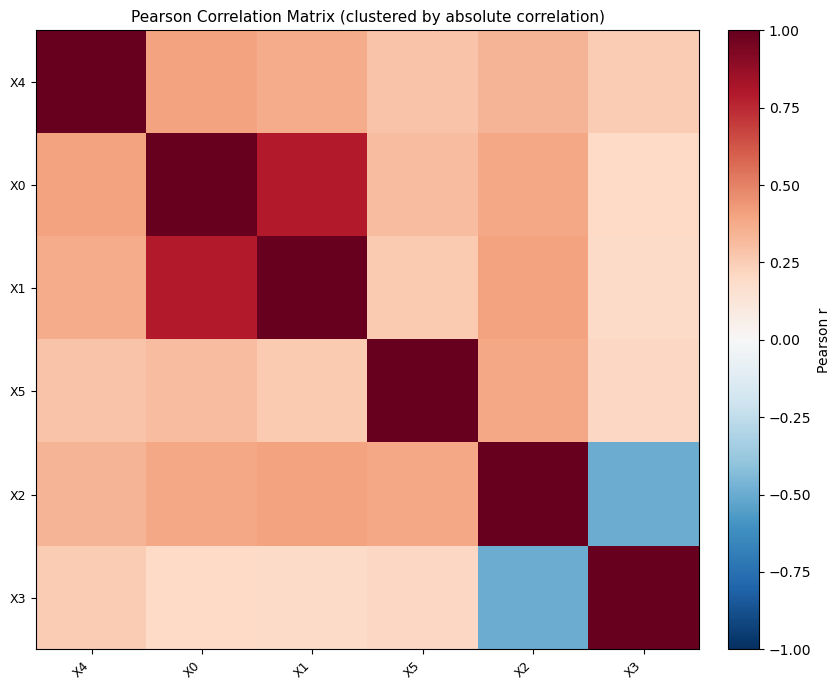

['X4', 'X0', 'X1', 'X5', 'X2', 'X3']

In [3]:
fig, ax, reordered = correlation_heatmap(
    X_background,
    feature_names,
    show=False,
)
display(fig)
plt.close(fig)
reordered

## Global Scores

`summary_bar` is the aggregate bar-chart helper for `phi_X`, `phi_Z`, and their standard errors.

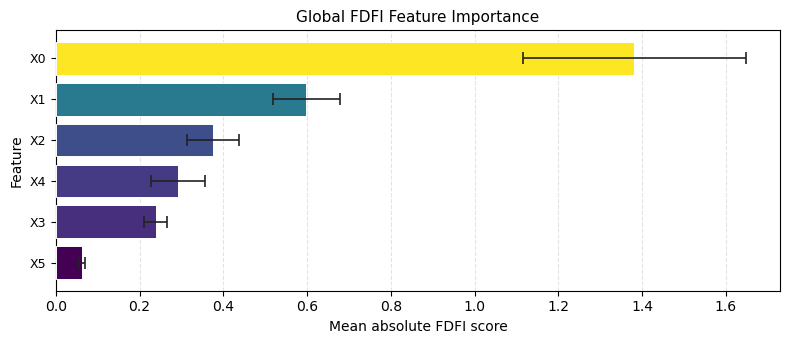

,feature,phi,se
0,X0,1.380897,0.266202
1,X1,0.598447,0.080826
2,X2,0.376329,0.062175
3,X4,0.290675,0.064366
4,X3,0.238167,0.026621


In [4]:
fig, ax, importance_table = summary_bar(
    results["phi_X"],
    results["se_X"],
    feature_names,
    show=False,
)
display(fig)
plt.close(fig)
importance_table.head()

## Per-sample UEIFs

After the explainer runs, `explainer.ueifs_X` stores per-sample X-space UEIFs. Use these for summary, dependence, waterfall, and force views.

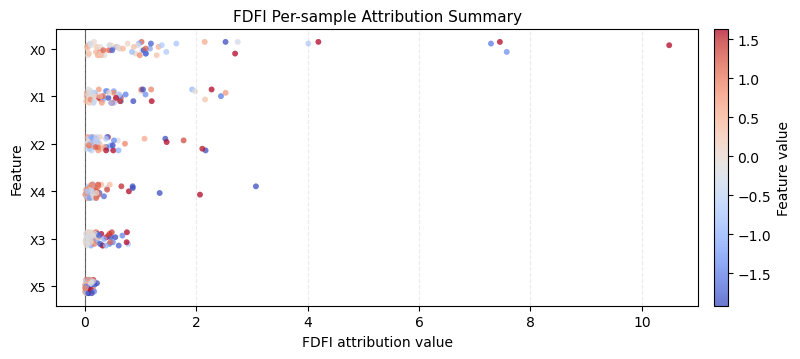

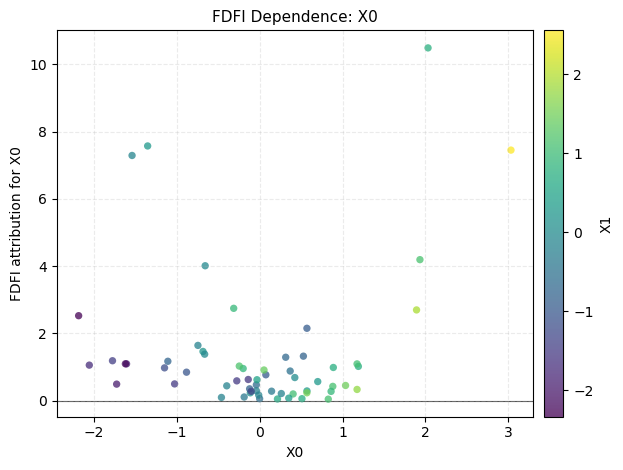

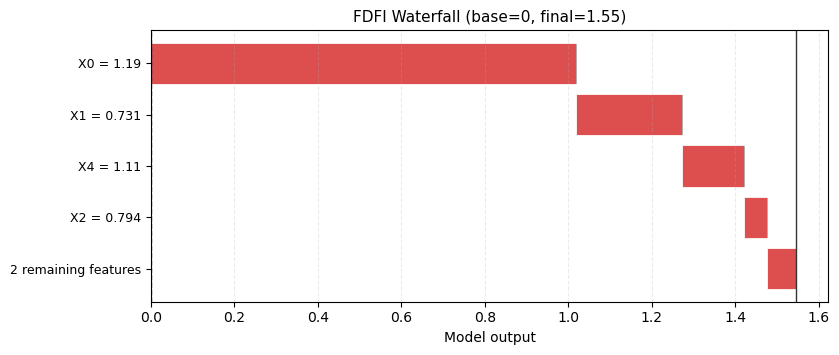

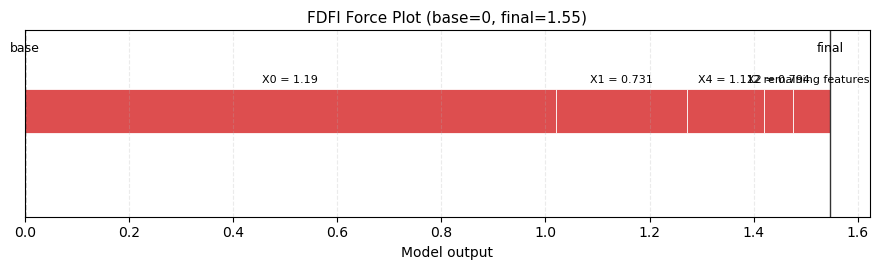

In [5]:
fig, ax = summary_plot(
    explainer.ueifs_X,
    features=X_test,
    feature_names=feature_names,
    show=False,
)
display(fig)
plt.close(fig)

fig, ax = dependence_plot(
    "X0",
    explainer.ueifs_X,
    X_test,
    feature_names=feature_names,
    interaction_index="X1",
    show=False,
)
display(fig)
plt.close(fig)

fig, ax = waterfall_plot(
    explainer.ueifs_X[0],
    features=X_test[0],
    feature_names=feature_names,
    max_display=5,
    show=False,
)
display(fig)
plt.close(fig)

fig, ax = force_plot(
    0.0,
    explainer.ueifs_X[0],
    features=X_test[0],
    feature_names=feature_names,
    max_display=5,
    show=False,
)
display(fig)
plt.close(fig)

## Inference and Diagnostics

`confidence_interval_plot` consumes `conf_int()` dictionaries. `diagnostics_plot` consumes the shared diagnostics dictionary from OT/EOT/Flow explainers.

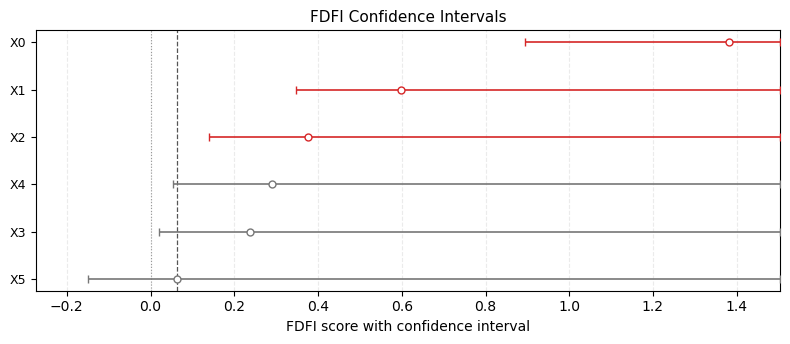

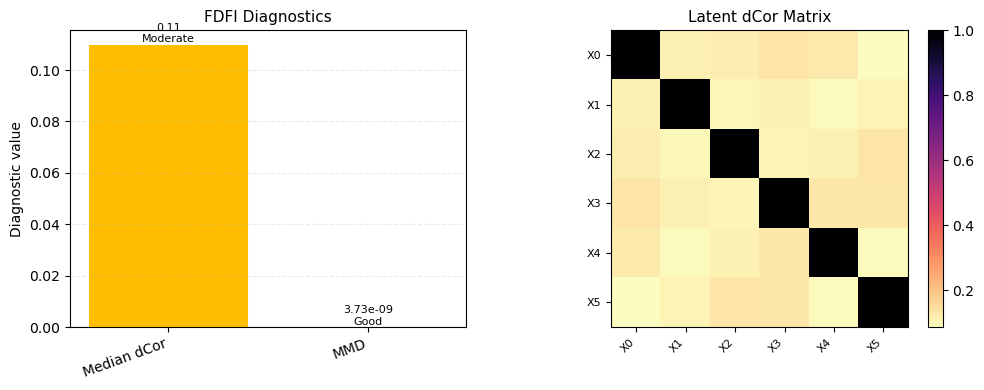

In [6]:
fig, ax = confidence_interval_plot(
    ci,
    feature_names=feature_names,
    show=False,
)
display(fig)
plt.close(fig)

fig, axes = diagnostics_plot(
    explainer.diagnostics,
    feature_names=feature_names,
    show=False,
)
display(fig)
plt.close(fig)